In [1]:
import os
import sys
import torch
import torch.nn as nn
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
sys.path.insert(0, '../ModelGenerator/huggingface/aido.cell')

from aido_cell.models import CellFoundationConfig
from aido_cell.models.modeling_cellfoundation import CellFoundationForMaskedLM
from aido_cell.utils import align_adata, preprocess_counts

/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
MODEL_NAME = "genbio-ai/AIDO.Cell-100M"
RAW_DATA_FILE = "../data/pbmc/pbmc3k_raw.h5ad"
PROCESSED_DATA_FILE = "../data/pbmc/pbmc3k_processed.h5ad"
OUTPUT_DIR = "../data/pbmc"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


STEERING_LAYER = 15  # Layer to apply steering (1-indexed, so layer index 14)
LEARNING_RATE = 0.01
NUM_ITERATIONS = 100
LAMBDA_NK = 1.0  # Weight for NK marker penalty
BATCH_SIZE = 4  # Process B-cells in batches to avoid OOM

TARGET_GENE = "S100A9"  # Monocyte marker to increase
NK_MARKERS = ["NKG7", "GNLY"]  # NK markers to minimize
BCELL_MARKERS = ["MS4A1", "CD79A", "CD79B"]  # For validation

In [4]:
class SteerableCellFoundation(nn.Module):
    """Wrapper around CellFoundationForMaskedLM with steering at a specific layer."""

    def __init__(self, model, steering_layer_idx, hidden_size, steering_vector=None):
        super().__init__()
        self.model = model
        self.steering_layer_idx = steering_layer_idx  # 0-indexed
        self.hidden_size = hidden_size

        # Learnable steering vector (broadcast across all gene positions)
        if steering_vector is not None:
            self.steering_vector = nn.Parameter(steering_vector)
        else:
            self.steering_vector = nn.Parameter(torch.zeros(hidden_size))

        # Hook handle
        self.hook_handle = None
        self._register_hook()

    def _register_hook(self):
        """Register a forward hook to modify hidden states at the specified layer."""
        def steering_hook(module, input, output):
            # output is a tuple (hidden_states, ...) from CellFoundationLayer
            hidden_states = output[0]
            # Add steering vector (broadcast across batch and sequence dimensions)
            steered_states = hidden_states + self.steering_vector.to(hidden_states.dtype)
            # Return modified output tuple
            return (steered_states,) + output[1:]

        # Access the specific layer in the encoder
        layer = self.model.bert.encoder.layer[self.steering_layer_idx]
        self.hook_handle = layer.register_forward_hook(steering_hook)

    def forward(self, input_ids, attention_mask):
        return self.model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)

    def remove_hook(self):
        if self.hook_handle is not None:
            self.hook_handle.remove()

In [5]:
def get_gene_indices(adata, gene_names):
    """Get indices of genes in the aligned adata."""
    indices = {}
    for gene in gene_names:
        if gene in adata.var_names:
            indices[gene] = list(adata.var_names).index(gene)
        else:
            print(f"Warning: Gene {gene} not found in aligned data")
    return indices

In [6]:
print("\n" + "="*60)
print("AIDO.Cell Steerability Test")
print("="*60)
print(f"Model: {MODEL_NAME}")
print(f"Steering layer: {STEERING_LAYER}")
print(f"Target gene: {TARGET_GENE}")
print(f"NK markers to minimize: {NK_MARKERS}")
print("="*60 + "\n")

# Load processed data for cell type annotations
print("Loading processed data for cell type annotations...")
adata_processed = ad.read_h5ad(PROCESSED_DATA_FILE)
print(f"Processed data shape: {adata_processed.shape}")


AIDO.Cell Steerability Test
Model: genbio-ai/AIDO.Cell-100M
Steering layer: 15
Target gene: S100A9
NK markers to minimize: ['NKG7', 'GNLY']

Loading processed data for cell type annotations...
Processed data shape: (2638, 1838)


/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


In [7]:
if 'louvain' in adata_processed.obs.columns:
        cell_types = adata_processed.obs['louvain']
else:
    raise ValueError("No cell type annotation found. Expected 'louvain' column.")

# Load raw data for model input
print("Loading raw data...")
adata_raw = ad.read_h5ad(RAW_DATA_FILE)
print(f"Raw data shape: {adata_raw.shape}")

# Find common cells between raw and processed
common_cells = adata_raw.obs_names.intersection(adata_processed.obs_names)
print(f"Common cells: {len(common_cells)}")

# Filter raw data to common cells and get cell types for those cells
adata_raw = adata_raw[common_cells].copy()
cell_types = cell_types.loc[common_cells]

Loading raw data...
Raw data shape: (2700, 32738)
Common cells: 2638


In [8]:
adata_aligned, attention_mask = align_adata(adata_raw)
print(f"Aligned data shape: {adata_aligned.shape}")

###########  Aligning data to AIDO.Cell  ###########
AIDO.Cell was pretrained on a fixed set of 19264 genes.
Aligning your data to the AIDO.Cell gene set...
15043 in your data that cannot be used by AIDO.Cell. Removing these.
['5S_rRNA' '7SK' '7SK-1' ... 'hsa-mir-7515' 'hsa-mir-8072' 'snoU13']
1569 genes in the AIDO.Cell pretraining set missing in your data.
AIDO.Cell is trained with zero-masking. Setting these to zero for AIDO.Cell to ignore.
['AARS1' 'ABHD18' 'ABITRAM' ... 'ZSCAN26' 'ZSWIM9' 'ZUP1']
17695 non-zero genes remaining.
Reordering genes to match AIDO.Cell gene ordering
Gathering attention mask for nonzero genes
####################  Finished  ####################
Aligned data shape: (2638, 19264)


In [9]:
adata_aligned.obs["cell_type"] = cell_types.values

/tmp/ipykernel_1246534/1878043395.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_aligned.obs["cell_type"] = cell_types.values


In [10]:
b_cell_mask = adata_aligned.obs["cell_type"] == "B cells"  
b_cell_mask = b_cell_mask.values

mono_mask = adata_aligned.obs["cell_type"] == "CD14+ Monocytes"
mono_mask = mono_mask.values

In [11]:
all_genes = [TARGET_GENE] + NK_MARKERS + BCELL_MARKERS
gene_indices = get_gene_indices(adata_aligned, all_genes)
print(f"Gene indices: {gene_indices}")

Gene indices: {'S100A9': 14256, 'NKG7': 10608, 'GNLY': 6402, 'MS4A1': 9889, 'CD79A': 2605, 'CD79B': 2606}


In [12]:
mono_raw_counts = adata_aligned.X[mono_mask]
if hasattr(mono_raw_counts, 'toarray'):
    mono_raw_counts = mono_raw_counts.toarray()

# Get B-cell raw counts
bcell_raw_counts = adata_aligned.X[b_cell_mask]
if hasattr(bcell_raw_counts, 'toarray'):
    bcell_raw_counts = bcell_raw_counts.toarray()

n_bcells = bcell_raw_counts.shape[0]
n_mono = mono_raw_counts.shape[0]

In [13]:
print(f"\nLoading model: {MODEL_NAME}")
config = CellFoundationConfig.from_pretrained(MODEL_NAME)
model = CellFoundationForMaskedLM.from_pretrained(MODEL_NAME, config=config)
model = model.to(DEVICE)

if DEVICE == "cuda":
    model = model.to(torch.bfloat16)

# Freeze all model parameters
for param in model.parameters():
    param.requires_grad = False

model.eval()
print("Model loaded and frozen")


Loading model: genbio-ai/AIDO.Cell-100M


/usr/users/nyanovsky/miniconda3/envs/aido_env/lib/python3.10/site-packages/huggingface_hub/file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Model loaded and frozen


In [14]:
all_genes += ['S100A8','CST3','TYROBP','KLRB1']
gene_indices = get_gene_indices(adata_aligned, all_genes)

In [15]:
# Get hidden size from config
hidden_size = config.hidden_size
print(f"Hidden size: {hidden_size}")

# Prepare attention mask
n_genes = adata_aligned.shape[1]
attn_mask_tensor = torch.from_numpy(attention_mask).unsqueeze(0).to(DEVICE)

# Run monocytes through model to get target S100A9 level
print("Running selected genes through model to get expression levels after forward pass...")
genes_predicted_expression = {gene:np.array([]) for gene in all_genes}
cell_embeddings = []

hidden_states = {}

def capture_hook(module, input, output):
    hidden_states['last_hidden_state'] = output

  # Register hook on the final layer norm of the encoder
hook_handle = model.bert.encoder.ln.register_forward_hook(capture_hook)

try:
    with torch.no_grad():
        for i in tqdm(range(0,adata_aligned.n_obs, BATCH_SIZE), desc="Processing monocytes"):

            batch_counts = adata_aligned[i:i+BATCH_SIZE].X.toarray()

            batch_processed = preprocess_counts(batch_counts, device=DEVICE)
            batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
            depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
            batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

            outputs = model(input_ids=batch_processed, attention_mask=batch_attn_mask, return_dict=True)
            gene_predictions = outputs.logits[:, :-2, :].squeeze(-1).float()
            for gene in all_genes:
                genes_predicted_expression[gene] = np.concatenate((genes_predicted_expression[gene], gene_predictions[:, gene_indices[gene]].cpu().numpy()))

            last_hidden_states = hidden_states["last_hidden_state"][:,:-2,:]
            last_hidden_states = last_hidden_states[:,attention_mask.astype(bool),:]

            cell_embeddings.append(last_hidden_states.mean(dim=1).float().cpu().numpy())
finally:
    hook_handle.remove()
# Calculate mean expression for each gene

cell_embeddings = np.concatenate(cell_embeddings, axis=0)

Hidden size: 640
Running selected genes through model to get expression levels after forward pass...


Processing monocytes:   0%|          | 0/660 [00:00<?, ?it/s]

Processing monocytes: 100%|██████████| 660/660 [18:55<00:00,  1.72s/it]


In [16]:
adata_aligned.obsm["pre_steer_emb"] = cell_embeddings

In [17]:
X_processed = preprocess_counts(adata_aligned.X.toarray(), device='cpu').numpy()

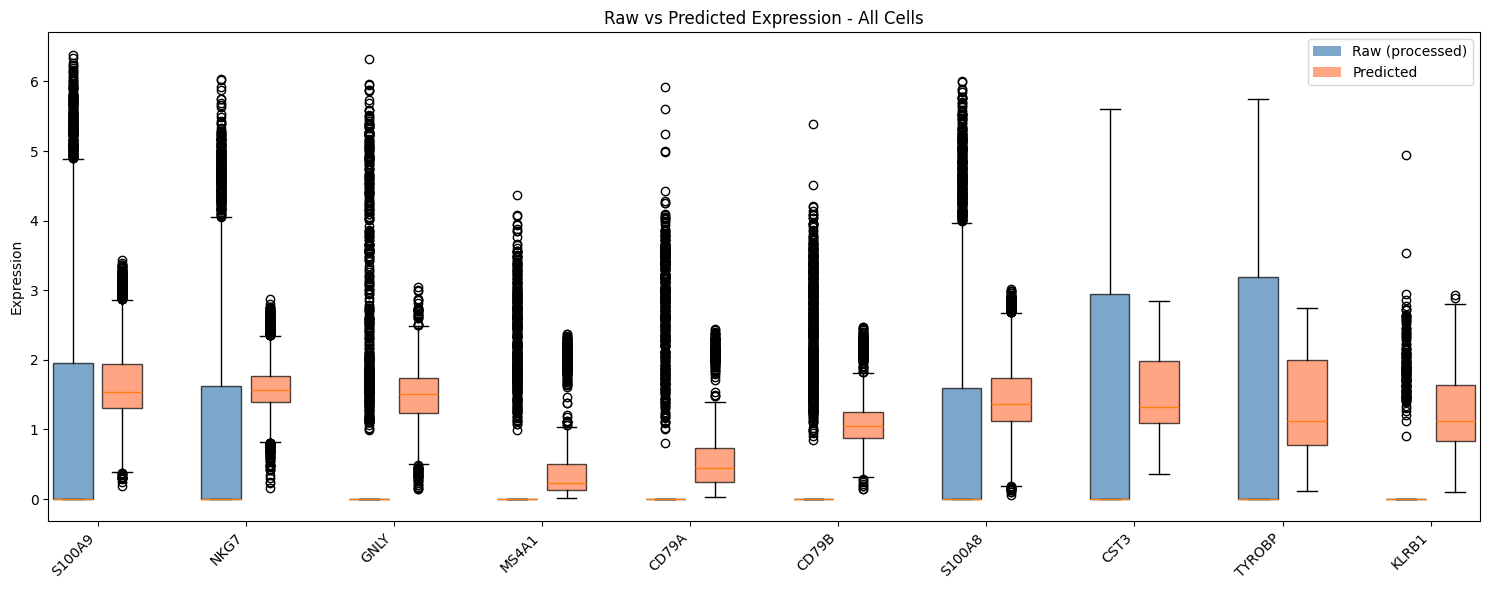

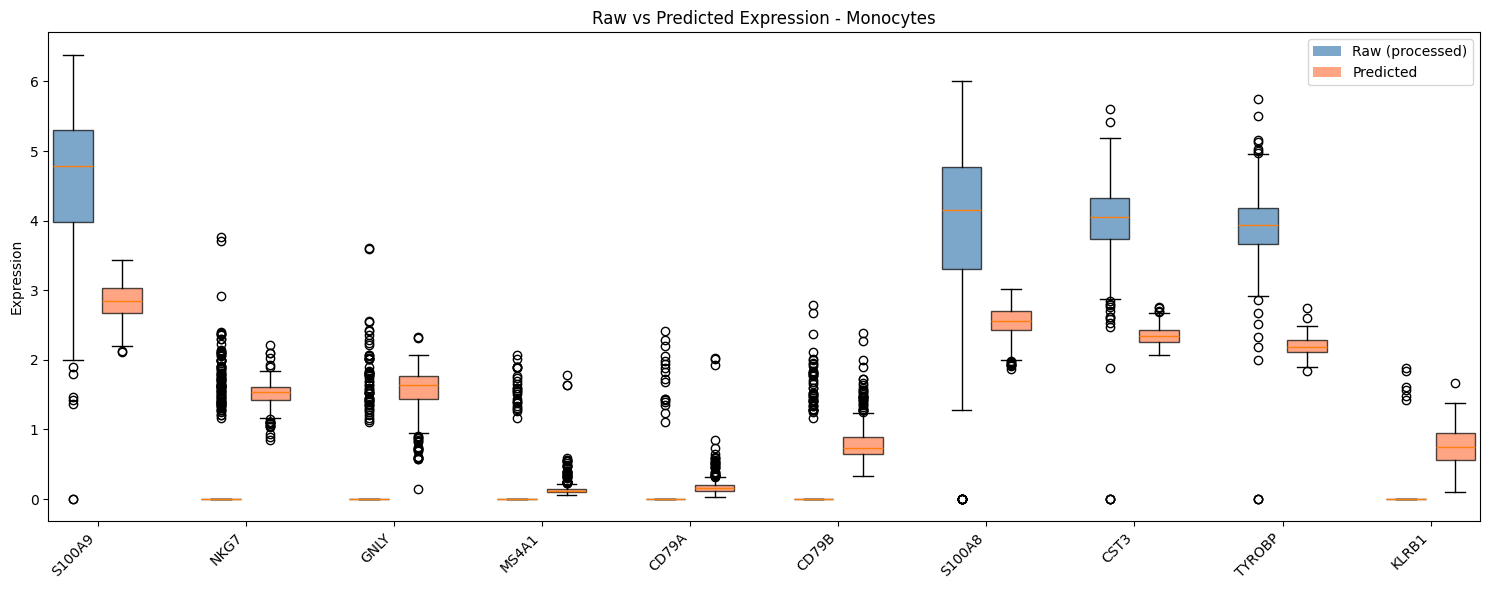

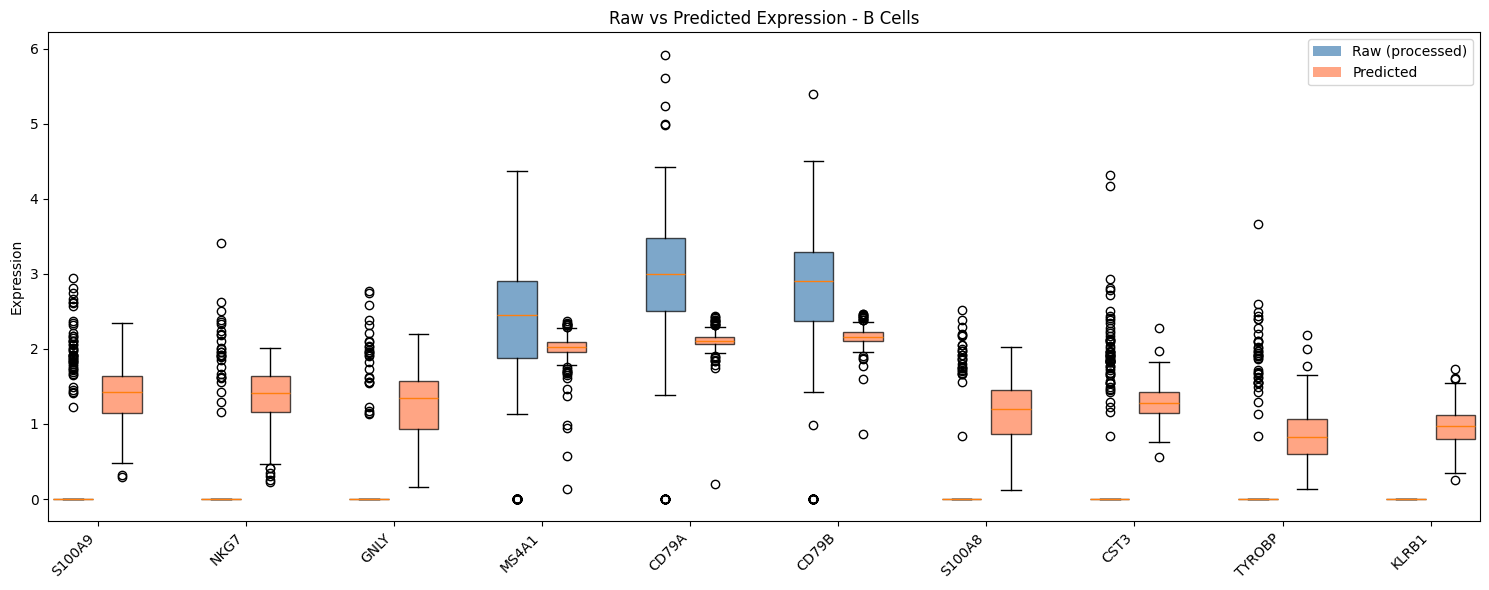

Saved figures to ../data/pbmc/


In [18]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_paired_boxplots(X_processed, genes_predicted_expression, gene_indices, mask=None, title="All Cells"):
    """Plot paired boxplots comparing raw vs predicted expression for each gene."""

    # Get the genes we're plotting
    genes = list(genes_predicted_expression.keys())

    # Prepare data for plotting
    data = []
    for gene in genes:
        idx = gene_indices[gene]

        if mask is not None:
            raw_expr = X_processed[mask, idx]
            pred_expr = genes_predicted_expression[gene][mask]
        else:
            raw_expr = X_processed[:, idx]
            pred_expr = genes_predicted_expression[gene]

        # Flatten if needed
        raw_expr = raw_expr.flatten() if hasattr(raw_expr, 'flatten') else raw_expr
        pred_expr = pred_expr.flatten() if hasattr(pred_expr, 'flatten') else pred_expr

        for val in raw_expr:
            data.append({'Gene': gene, 'tipo': 'Raw', 'Expression': val})
        for val in pred_expr:
            data.append({'Gene': gene, 'tipo': 'Predicted', 'Expression': val})

    df = pd.DataFrame(data)

    # Create figure
    fig, ax = plt.subplots(figsize=(max(12, len(genes) * 1.5), 6))

    # Create paired boxplots
    genes_positions = []
    for i, gene in enumerate(genes):
        pos_raw = i * 3
        pos_pred = i * 3 + 1
        genes_positions.append(i * 3 + 0.5)

        gene_df = df[df['Gene'] == gene]
        raw_data = gene_df[gene_df['tipo'] == 'Raw']['Expression'].values
        pred_data = gene_df[gene_df['tipo'] == 'Predicted']['Expression'].values

        bp1 = ax.boxplot([raw_data], positions=[pos_raw], widths=0.8,
                        patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.7))
        bp2 = ax.boxplot([pred_data], positions=[pos_pred], widths=0.8,
                        patch_artist=True, boxprops=dict(facecolor='coral', alpha=0.7))

    # Customize plot
    ax.set_xticks(genes_positions)
    ax.set_xticklabels(genes, rotation=45, ha='right')
    ax.set_ylabel('Expression')
    ax.set_title(title)

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Raw (processed)'),
                        Patch(facecolor='coral', alpha=0.7, label='Predicted')]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    return fig

# Convert X_processed to dense if sparse
if hasattr(X_processed, 'toarray'):
    X_processed_dense = X_processed.toarray()
else:
    X_processed_dense = X_processed

# Figure 1: All cells
fig1 = plot_paired_boxplots(X_processed_dense, genes_predicted_expression, gene_indices,
                            mask=None, title="Raw vs Predicted Expression - All Cells")
fig1.savefig("../data/pbmc/boxplot_all_cells.png", dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Monocytes only
fig2 = plot_paired_boxplots(X_processed_dense, genes_predicted_expression, gene_indices,
                            mask=mono_mask, title="Raw vs Predicted Expression - Monocytes")
fig2.savefig("../data/pbmc/boxplot_monocytes.png", dpi=150, bbox_inches='tight')
plt.show()

# Figure 3: B-cells only
fig3 = plot_paired_boxplots(X_processed_dense, genes_predicted_expression, gene_indices,
                            mask=b_cell_mask, title="Raw vs Predicted Expression - B Cells")
fig3.savefig("../data/pbmc/boxplot_bcells.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved figures to ../data/pbmc/")

In [18]:
steering_vector = torch.load("../data/pbmc/steering_vector.pt")

In [21]:
steerable_model = SteerableCellFoundation(
    model,
    steering_layer_idx=STEERING_LAYER - 1,  # Convert to 0-indexed
    hidden_size=hidden_size,
    steering_vector=steering_vector
)
steerable_model = steerable_model.to(DEVICE)

In [19]:
steerable_model = SteerableCellFoundation(
    model,
    steering_layer_idx=STEERING_LAYER - 1,  # Convert to 0-indexed
    hidden_size=hidden_size
)
steerable_model = steerable_model.to(DEVICE)

# Optimizer for steering vector only
optimizer = torch.optim.Adam([steerable_model.steering_vector], lr=0.1)

In [20]:
print(f"\nOptimizing steering vector...")
print(f"Iterations: {NUM_ITERATIONS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Lambda (NK penalty): {LAMBDA_NK}")
print(f"Batch size: {BATCH_SIZE}")

target_s100a9 = 4.56
target_nk = 0.15

losses = []
s100a9_values = []
nk_values = []

# Target tensor
target_s100a9_tensor = torch.tensor(target_s100a9, device=DEVICE, dtype=torch.float32)
target_nk_tensor = torch.tensor(target_nk, device=DEVICE, dtype=torch.float32)

n_batches = (n_bcells + BATCH_SIZE - 1) // BATCH_SIZE

for iteration in tqdm(range(40), desc="Optimizing"):
    optimizer.zero_grad()

    # Accumulate gradients over all B-cells in batches
    total_s100a9 = 0.0
    total_nkg7 = 0.0
    total_gnly = 0.0
    total_loss = 0.0

    for batch_idx in range(n_batches):
        start_idx = batch_idx * BATCH_SIZE
        end_idx = min(start_idx + BATCH_SIZE, n_bcells)
        batch_counts = bcell_raw_counts[start_idx:end_idx]

        # Preprocess B-cell counts
        batch_processed = preprocess_counts(batch_counts, device=DEVICE)

        # Expand attention mask
        batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
        depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
        batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

        # Forward pass with steering
        steerable_model.steering_vector.requires_grad_(True)

        outputs = steerable_model(
            input_ids=batch_processed,
            attention_mask=batch_attn_mask
        )

        # Get gene predictions
        logits = outputs.logits  # [batch, 19266, 1]
        gene_predictions = logits[:, :-2, :].squeeze(-1).float()  # [batch, 19264]

        # Extract target gene expressions (sum for accumulation)
        batch_size_actual = gene_predictions.shape[0]
        s100a9_pred = gene_predictions[:, gene_indices[TARGET_GENE]].sum()
        nkg7_pred = gene_predictions[:, gene_indices['NKG7']].sum() if 'NKG7' in gene_indices else torch.tensor(0.0, device=DEVICE)
        gnly_pred = gene_predictions[:, gene_indices['GNLY']].sum() if 'GNLY' in gene_indices else torch.tensor(0.0, device=DEVICE)

        total_s100a9 += s100a9_pred
        total_nkg7 += nkg7_pred
        total_gnly += gnly_pred

        # Compute batch loss (scaled by batch size for proper averaging)
        batch_s100a9_mean = s100a9_pred / batch_size_actual
        batch_nk_mean = (nkg7_pred + gnly_pred) / batch_size_actual
        batch_loss = (batch_s100a9_mean - target_s100a9_tensor) ** 2 + LAMBDA_NK * (batch_nk_mean-target_nk_tensor)**2

        # Scale loss by batch proportion for gradient accumulation
        batch_loss = batch_loss * (batch_size_actual / n_bcells)
        batch_loss.backward()

        total_loss += batch_loss.item()

    # Update steering vector
    optimizer.step()

    # Record metrics (averages across all B-cells)
    avg_s100a9 = total_s100a9.item() / n_bcells
    avg_nk = (total_nkg7.item() + total_gnly.item()) / (2 * n_bcells)

    losses.append(total_loss)
    s100a9_values.append(avg_s100a9)
    nk_values.append(avg_nk)

    if (iteration + 1) % 2 == 0:
        print(f"  Iter {iteration+1}: Loss={total_loss:.4f}, "
                f"S100A9={avg_s100a9:.4f}, "
                f"NK avg={avg_nk:.4f}")

print("\nOptimization complete!")
print(f"Final S100A9: {s100a9_values[-1]:.4f} (target: {target_s100a9:.4f})")
print(f"Final NK avg: {nk_values[-1]:.4f}")


Optimizing steering vector...
Iterations: 100
Learning rate: 0.01
Lambda (NK penalty): 1.0
Batch size: 4


Optimizing:   5%|▌         | 2/40 [06:40<2:06:49, 200.26s/it]

  Iter 2: Loss=14.9440, S100A9=1.3282, NK avg=1.1095


Optimizing:  10%|█         | 4/40 [13:22<2:00:30, 200.86s/it]

  Iter 4: Loss=12.6928, S100A9=1.2713, NK avg=0.7231


...

  Iter 36: Loss=1.0167, S100A9=3.5935, NK avg=0.1573


Optimizing:  95%|█████████▌| 38/40 [2:07:01<06:41, 200.78s/it]

  Iter 38: Loss=0.7768, S100A9=3.7228, NK avg=0.1465


Optimizing: 100%|██████████| 40/40 [2:13:42<00:00, 200.57s/it]

  Iter 40: Loss=0.5702, S100A9=3.8537, NK avg=0.1362

Optimization complete!
Final S100A9: 3.8537 (target: 4.5600)
Final NK avg: 0.1362


In [23]:
print("\nCollecting steered cell embeddings...")

steered_cell_embeddings = []
steered_hidden_states = {}

steered_gene_preds = {gene:np.array([]) for gene in all_genes}

def capture_steered_hook(module, input, output):
    steered_hidden_states['last_hidden_state'] = output

# Register hook on the final layer norm
hook_handle = steerable_model.model.bert.encoder.ln.register_forward_hook(capture_steered_hook)

try:
    with torch.no_grad():
        for i in tqdm(range(0, adata_aligned.n_obs, BATCH_SIZE), desc="Collecting steered embeddings"):
            batch_counts = adata_aligned[i:i+BATCH_SIZE].X.toarray()

            batch_processed = preprocess_counts(batch_counts, device=DEVICE)
            batch_attn_mask = attn_mask_tensor.repeat(batch_processed.shape[0], 1)
            depth_token_mask = torch.ones((batch_processed.shape[0], 2), device=DEVICE)
            batch_attn_mask = torch.cat([batch_attn_mask, depth_token_mask], dim=1)

            # Forward pass WITH steering
            outputs = steerable_model(input_ids=batch_processed, attention_mask=batch_attn_mask)

            gene_predictions = outputs.logits[:, :-2, :].squeeze(-1).float()

            for gene in all_genes:
                steered_gene_preds[gene] = np.concatenate((steered_gene_preds[gene], gene_predictions[:, gene_indices[gene]].cpu().numpy()))

            # Get the captured hidden state from hook
            last_hidden = steered_hidden_states['last_hidden_state'][:, :-2, :]
            last_hidden = last_hidden[:,attention_mask.astype(bool), :]
            steered_cell_embeddings.append(last_hidden.mean(dim=1).float().cpu().numpy())
finally:
    hook_handle.remove()

steered_cell_embeddings = np.concatenate(steered_cell_embeddings, axis=0)
adata_aligned.obsm["post_steer_emb"] = steered_cell_embeddings
print(f"Steered embeddings shape: {steered_cell_embeddings.shape}")

Steered embeddings shape: (2638, 640)


In [24]:
print("\n" + "="*60)
print("Validation: Comparing before/after steering")
print("="*60)

# Calculate expression changes
print("\nExpression changes in B-cells (averaged over all B-cells):")
print("-" * 50)
print(f"{'Gene':<10} {'Before':<12} {'After':<12} {'Change':<12}")
print("-" * 50)

results = {}
for gene in all_genes:
    if gene in gene_indices:
        idx = gene_indices[gene]
        before = genes_predicted_expression[gene][b_cell_mask].mean()
        after = steered_gene_preds[gene][b_cell_mask].mean()
        change = after - before
        results[gene] = {'before': before, 'after': after, 'change': change}
        print(f"{gene:<10} {before:<12.4f} {after:<12.4f} {change:+.4f}")

print("-" * 50)


Validation: Comparing before/after steering

Expression changes in B-cells (averaged over all B-cells):
--------------------------------------------------
Gene       Before       After        Change      
--------------------------------------------------
S100A9     1.3674       3.9199       +2.5525
NKG7       1.3617       0.2022       -1.1594
GNLY       1.2427       0.0585       -1.1842
MS4A1      2.0068       1.4190       -0.5878
CD79A      2.1036       2.1838       +0.0802
CD79B      2.1607       1.4931       -0.6676
S100A8     1.1349       3.5938       +2.4588
CST3       1.2760       1.2205       -0.0554
TYROBP     0.8333       0.4056       -0.4277
KLRB1      0.9561       0.1903       -0.7658
--------------------------------------------------


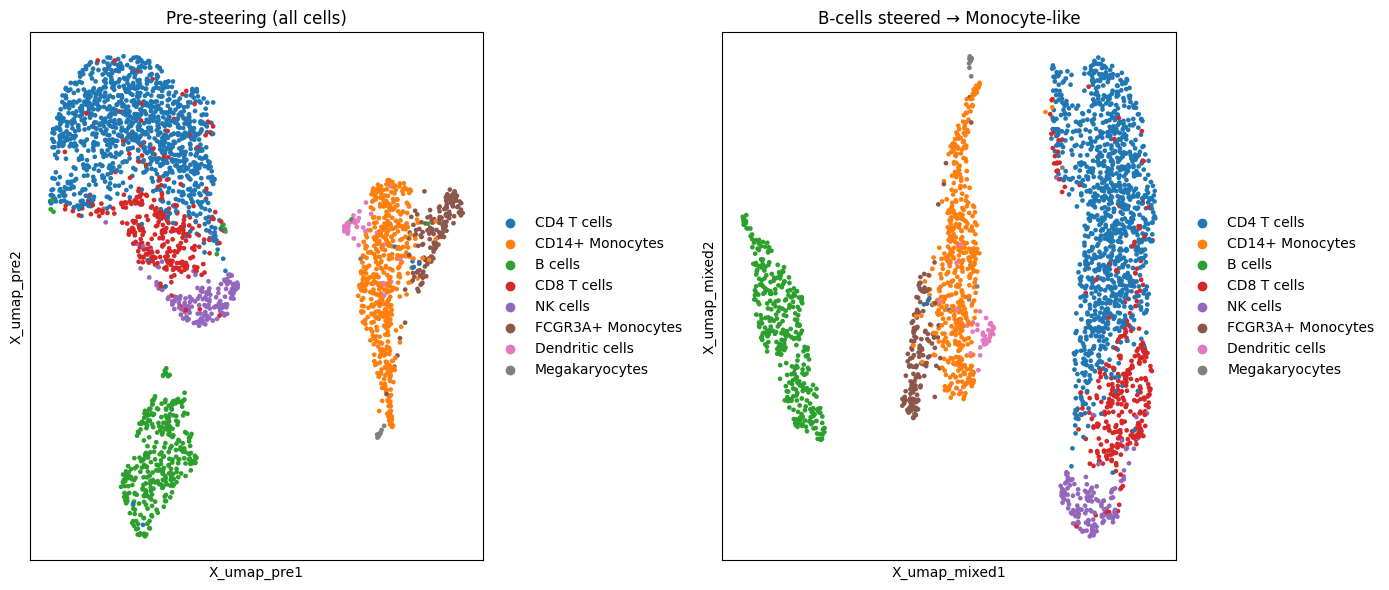

In [29]:
import scanpy as sc

mixed_embeddings = adata_aligned.obsm["pre_steer_emb"].copy()
mixed_embeddings[b_cell_mask] = steered_cell_embeddings[b_cell_mask]
adata_aligned.obsm["mixed_steer_emb"] = mixed_embeddings

# Compute UMAP for pre-steer embeddings
sc.pp.neighbors(adata_aligned, use_rep="pre_steer_emb", key_added="pre_steer")
sc.tl.umap(adata_aligned, neighbors_key="pre_steer")
adata_aligned.obsm["X_umap_pre"] = adata_aligned.obsm["X_umap"].copy()

# Compute UMAP for mixed embeddings (B-cells steered, others not)
sc.pp.neighbors(adata_aligned, use_rep="mixed_steer_emb", key_added="mixed_steer")
sc.tl.umap(adata_aligned, neighbors_key="mixed_steer")
adata_aligned.obsm["X_umap_mixed"] = adata_aligned.obsm["X_umap"].copy()

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(adata_aligned, basis="X_umap_pre", color="cell_type", ax=axes[0], show=False, title="Pre-steering (all cells)")
sc.pl.embedding(adata_aligned, basis="X_umap_mixed", color="cell_type", ax=axes[1], show=False, title="B-cells steered → Monocyte-like")
plt.tight_layout()
plt.savefig("../plots/umap_bcell_steering.png", dpi=150)
plt.show()

In [27]:
# save steering vector
steering_vector_path = os.path.join(OUTPUT_DIR, "steering_vector.pt")
torch.save(steerable_model.steering_vector.data.cpu(), steering_vector_path)
print(f"\nSteering vector saved to: {steering_vector_path}")


Steering vector saved to: ../data/pbmc/steering_vector.pt


Distance Analysis: B-cells to Monocyte Centroid

Pre-steer distance:  1.4616 +/- 0.3175
Post-steer distance: 11.1127 +/- 0.2468

Mean change: 9.6511
Median change: 9.6814

B-cells that moved closer: 0/342 (0.0%)

Paired t-test: t=-1141.0271, p=0.00e+00


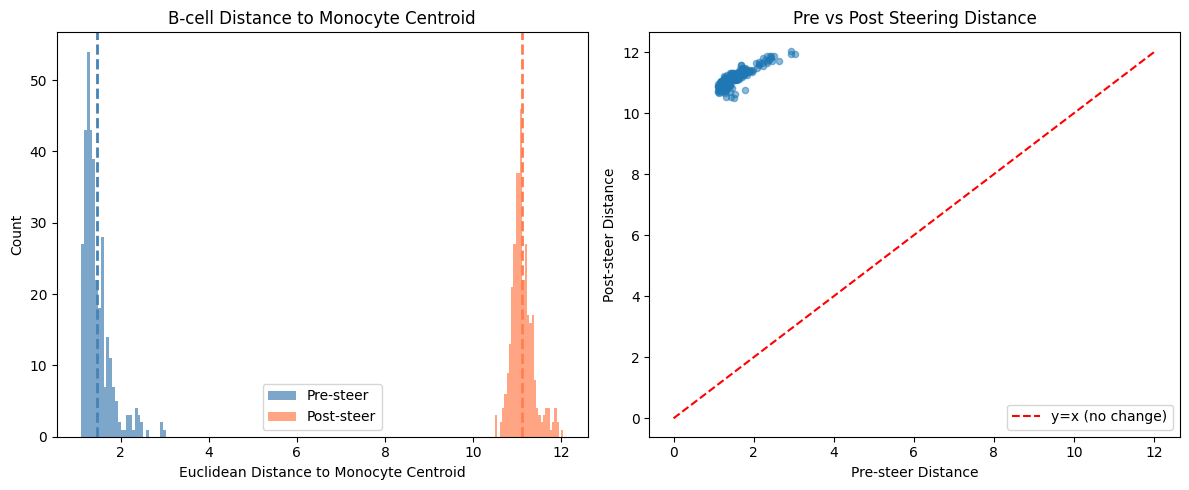


Plot saved to ../plots/bcell_distance_analysis.png


In [30]:
# Distance Analysis: Quantify B-cell to Monocyte movement
from scipy import stats

# Get embeddings
bcell_pre_emb = adata_aligned.obsm["pre_steer_emb"][b_cell_mask]
bcell_post_emb = adata_aligned.obsm["post_steer_emb"][b_cell_mask]

# Compute monocyte centroid (from pre-steer embeddings as stable reference)
mono_centroid = adata_aligned.obsm["pre_steer_emb"][mono_mask].mean(axis=0)

# Compute Euclidean distance from each B-cell to monocyte centroid
dist_pre = np.linalg.norm(bcell_pre_emb - mono_centroid, axis=1)
dist_post = np.linalg.norm(bcell_post_emb - mono_centroid, axis=1)

# Print statistics
print("="*60)
print("Distance Analysis: B-cells to Monocyte Centroid")
print("="*60)
print(f"\nPre-steer distance:  {dist_pre.mean():.4f} +/- {dist_pre.std():.4f}")
print(f"Post-steer distance: {dist_post.mean():.4f} +/- {dist_post.std():.4f}")
print(f"\nMean change: {(dist_post - dist_pre).mean():.4f}")
print(f"Median change: {np.median(dist_post - dist_pre):.4f}")

# Percentage of B-cells that moved closer to monocytes
moved_closer = (dist_post < dist_pre).sum()
total_bcells = len(dist_pre)
print(f"\nB-cells that moved closer: {moved_closer}/{total_bcells} ({100*moved_closer/total_bcells:.1f}%)")

# Paired t-test
t_stat, p_value = stats.ttest_rel(dist_pre, dist_post)
print(f"\nPaired t-test: t={t_stat:.4f}, p={p_value:.2e}")

# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of distances
axes[0].hist(dist_pre, bins=30, alpha=0.7, label='Pre-steer', color='steelblue')
axes[0].hist(dist_post, bins=30, alpha=0.7, label='Post-steer', color='coral')
axes[0].axvline(dist_pre.mean(), color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(dist_post.mean(), color='coral', linestyle='--', linewidth=2)
axes[0].set_xlabel('Euclidean Distance to Monocyte Centroid')
axes[0].set_ylabel('Count')
axes[0].set_title('B-cell Distance to Monocyte Centroid')
axes[0].legend()

# Scatter plot: pre vs post distance
axes[1].scatter(dist_pre, dist_post, alpha=0.5, s=20)
max_dist = max(dist_pre.max(), dist_post.max())
axes[1].plot([0, max_dist], [0, max_dist], 'r--', label='y=x (no change)')
axes[1].set_xlabel('Pre-steer Distance')
axes[1].set_ylabel('Post-steer Distance')
axes[1].set_title('Pre vs Post Steering Distance')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/bcell_distance_analysis.png', dpi=150)
plt.show()

print(f"\nPlot saved to ../plots/bcell_distance_analysis.png")